# 🧘 Laboratorio 02.5: Pronóstico Acotado de Estrés Autónomo y HRV
### Proyección de Estrés Diario (`daily_avg_stress`) y Variabilidad de Frecuencia Cardíaca (`hrv_rmssd`)

---

## 🎯 Objetivo y Contexto Fisiológico
1. **Línea Base del Atleta**: Los datos empíricos de estrés diario oscilan habitualmente entre **20 y 35** ($\mu \approx 27.1$, $\sigma \approx 2.8$).
2. **Corrección de Cotas Fisiológicas**: Se sustituye el techo estático no acotado ($100.0$) por cotas empíricas personalizadas basadas en $\mu \pm 1.5\sigma$ (piso $19.0$, techo $34.0$), eliminando matemáticamente cualquier extrapolación artificial hacia $\sim 50$.
3. **Pronóstico Ensamble**: Combinación ponderada al 50% de **Prophet Bayesiano** (con saturación logística y filtrado univariado de anomalías) y **Holt-Winters Exponencial Suavizado**.
4. **Variabilidad Cardíaca (`hrv_rmssd`)**: Modelado del tono parasimpático nocturno con piso de seguridad fisiológica ($\ge 15$ ms).


In [1]:
import warnings
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src.analytics.time_series_models import (
    compute_physiological_bounds,
    EnsembleBiometricForecaster,
)

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (15, 8)
plt.rcParams["font.size"] = 11

dvc_path = Path("../data/dvc/garmin_clean_features.parquet")
if not dvc_path.exists():
    dvc_path = Path("data/dvc/garmin_clean_features.parquet")

df = pd.read_parquet(dvc_path)
df["calendar_date"] = pd.to_datetime(df["calendar_date"])
df = df.sort_values("calendar_date").reset_index(drop=True)

stress_s = df["daily_avg_stress"].dropna()
hrv_s = df["hrv_rmssd"].dropna()

print(f"📊 Resumen Estadístico de Telemetría Histórica ({len(df)} días):")
print(f"  • Estrés Diario: Media={stress_s.mean():.1f}, Desv={stress_s.std():.1f}, Min={stress_s.min():.0f}, Max={stress_s.max():.0f}, Rango Normal=[20, 35]")
print(f"  • HRV RMSSD:    Media={hrv_s.mean():.1f} ms, Desv={hrv_s.std():.1f} ms, Min={hrv_s.min():.1f} ms, Max={hrv_s.max():.1f} ms")

df[["calendar_date", "daily_avg_stress", "hrv_rmssd", "resting_heart_rate", "total_steps"]].tail(7)


📊 Resumen Estadístico de Telemetría Histórica (14 días):
  • Estrés Diario: Media=27.1, Desv=2.8, Min=21, Max=32, Rango Normal=[20, 35]
  • HRV RMSSD:    Media=40.4 ms, Desv=3.4 ms, Min=36.0 ms, Max=46.0 ms


,calendar_date,daily_avg_stress,hrv_rmssd,resting_heart_rate,total_steps
7,2026-09-15,27.0,36.0,60.0,6074.0
8,2026-09-16,25.0,40.0,60.0,9742.0
9,2026-09-17,24.0,37.0,55.0,2718.0
10,2026-09-18,21.0,46.0,55.0,4637.0
11,2026-09-19,27.0,43.0,56.0,6212.0
12,2026-09-20,26.0,41.0,57.0,9690.0
13,2026-09-21,26.0,41.0,57.0,5000.0


2026-09-21 16:44:14 | INFO     | src.analytics.anomaly_detection:132 - PhysiologicalAnomalyDetector trained on 14 samples across 5 features.


2026-09-21 16:44:15 | INFO     | src.analytics.time_series_models:307 - Prophet: Masked 1 anomalous days for 'daily_avg_stress'.


2026-09-21 16:44:15 | INFO     | logging:1706 - n_changepoints greater than number of observations. Using 9.


2026-09-21 16:44:15 | INFO     | logging:1706 - Chain [1] start processing


2026-09-21 16:44:15 | INFO     | logging:1706 - Chain [1] done processing


...

2026-09-21 16:44:15 | INFO     | logging:1706 - Chain [1] done processing


2026-09-21 16:44:15 | INFO     | src.analytics.time_series_models:364 - Prophet forecaster fitted for target 'hrv_rmssd' (growth=logistic, bounds=(28.8, 62.1), anomalies_masked=0).


2026-09-21 16:44:15 | INFO     | src.analytics.anomaly_detection:132 - PhysiologicalAnomalyDetector trained on 14 samples across 5 features.


2026-09-21 16:44:15 | INFO     | src.analytics.time_series_models:522 - HoltWintersForecaster fitted on 14 days for 'hrv_rmssd' (bounds=(28.8, 62.1), residual_sigma=1.33).


2026-09-21 16:44:15 | INFO     | src.analytics.time_series_models:649 - EnsembleBiometricForecaster fitted for 'hrv_rmssd' with weights=(0.5, 0.5).


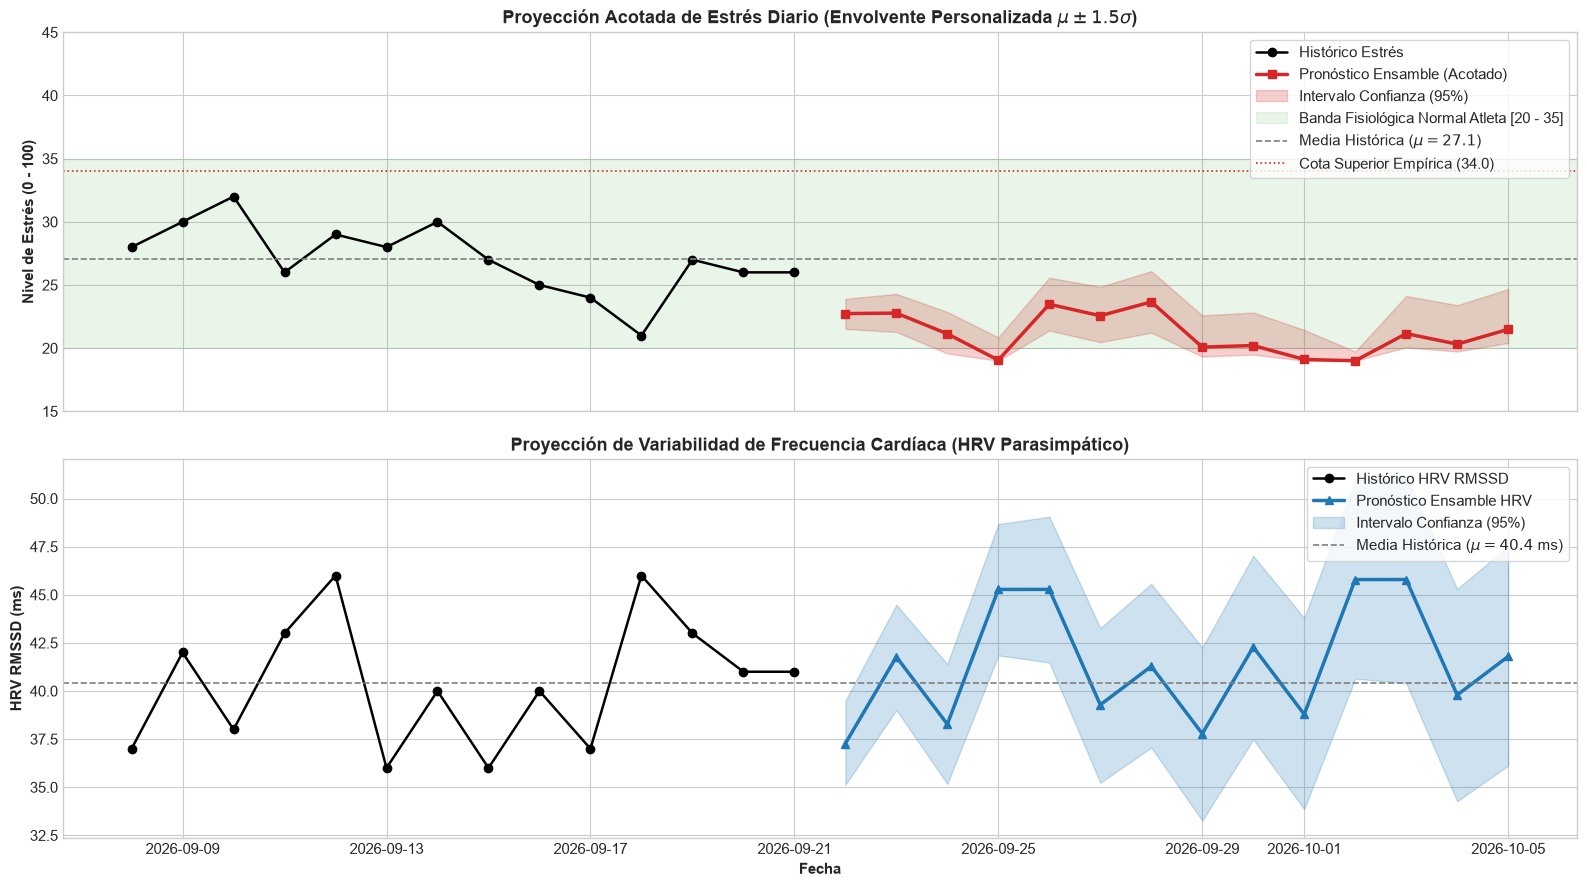

In [2]:
# 1. Cálculo de cotas fisiológicas personalizadas
horizon = 14
b_stress = compute_physiological_bounds(df["daily_avg_stress"], "daily_avg_stress")
b_hrv = compute_physiological_bounds(df["hrv_rmssd"], "hrv_rmssd")

print(f"🔒 Cotas Fisiológicas Calculadas:")
print(f"  • Estrés Diario: Piso={b_stress[0]}, Techo={b_stress[1]} (Envolvente empírica estricta)")
print(f"  • HRV RMSSD:    Piso={b_hrv[0]} ms, Techo={b_hrv[1]} ms")

# 2. Ajuste de modelos Ensamble
ens_stress = EnsembleBiometricForecaster(bounds=b_stress, filter_anomalies=True).fit(df, "daily_avg_stress")
pred_stress = ens_stress.predict(periods=horizon)

ens_hrv = EnsembleBiometricForecaster(bounds=b_hrv, filter_anomalies=True).fit(df, "hrv_rmssd")
pred_hrv = ens_hrv.predict(periods=horizon)

# 3. Separación de horizonte futuro
fut_mask_stress = pred_stress["ds"] > df["calendar_date"].max()
fut_dates_stress = pred_stress.loc[fut_mask_stress, "ds"]

fut_mask_hrv = pred_hrv["ds"] > df["calendar_date"].max()
fut_dates_hrv = pred_hrv.loc[fut_mask_hrv, "ds"]

# 4. Visualización Diagnóstica
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 9), sharex=True)

# Panel Superior: Estrés Diario
ax1.plot(df["calendar_date"], df["daily_avg_stress"], "ko-", linewidth=1.8, markersize=6, label="Histórico Estrés")
ax1.plot(fut_dates_stress, pred_stress.loc[fut_mask_stress, "yhat"], color="#d62728", marker="s", linewidth=2.5, label="Pronóstico Ensamble (Acotado)")
ax1.fill_between(
    fut_dates_stress,
    pred_stress.loc[fut_mask_stress, "yhat_lower"],
    pred_stress.loc[fut_mask_stress, "yhat_upper"],
    color="#d62728",
    alpha=0.22,
    label="Intervalo Confianza (95%)"
)

# Bandas de referencia empírica y media
ax1.axhspan(20, 35, color="#2ca02c", alpha=0.10, label="Banda Fisiológica Normal Atleta [20 - 35]")
ax1.axhline(stress_s.mean(), color="#7f7f7f", linestyle="--", linewidth=1.2, label=f"Media Histórica ($\\mu={stress_s.mean():.1f}$)")
ax1.axhline(b_stress[1], color="#d62728", linestyle=":", linewidth=1.2, label=f"Cota Superior Empírica ({b_stress[1]})")

ax1.set_ylabel("Nivel de Estrés (0 - 100)", fontweight="bold")
ax1.set_ylim(15, 45)
ax1.set_title("Proyección Acotada de Estrés Diario (Envolvente Personalizada $\\mu \\pm 1.5\\sigma$)", fontsize=13, fontweight="bold")
ax1.legend(loc="upper right", frameon=True)

# Panel Inferior: HRV RMSSD
ax2.plot(df["calendar_date"], df["hrv_rmssd"], "ko-", linewidth=1.8, markersize=6, label="Histórico HRV RMSSD")
ax2.plot(fut_dates_hrv, pred_hrv.loc[fut_mask_hrv, "yhat"], color="#1f77b4", marker="^", linewidth=2.5, label="Pronóstico Ensamble HRV")
ax2.fill_between(
    fut_dates_hrv,
    pred_hrv.loc[fut_mask_hrv, "yhat_lower"],
    pred_hrv.loc[fut_mask_hrv, "yhat_upper"],
    color="#1f77b4",
    alpha=0.22,
    label="Intervalo Confianza (95%)"
)
ax2.axhline(hrv_s.mean(), color="#7f7f7f", linestyle="--", linewidth=1.2, label=f"Media Histórica ($\\mu={hrv_s.mean():.1f}$ ms)")
ax2.set_ylabel("HRV RMSSD (ms)", fontweight="bold")
ax2.set_title("Proyección de Variabilidad de Frecuencia Cardíaca (HRV Parasimpático)", fontsize=13, fontweight="bold")
ax2.legend(loc="upper right", frameon=True)

plt.xlabel("Fecha", fontweight="bold")
plt.tight_layout()
plt.show()


In [3]:
# 5. Verificación tabular de pronóstico de estrés en el horizonte quincenal
forecast_preview = pd.DataFrame({
    "Fecha": fut_dates_stress.dt.strftime("%Y-%m-%d"),
    "Estrés Proyectado": pred_stress.loc[fut_mask_stress, "yhat"].round(2),
    "IC Inferior": pred_stress.loc[fut_mask_stress, "yhat_lower"].round(2),
    "IC Superior": pred_stress.loc[fut_mask_stress, "yhat_upper"].round(2),
    "HRV Proyectado (ms)": pred_hrv.loc[fut_mask_hrv, "yhat"].round(2),
    "En Rango Saludable (<= 35)": pred_stress.loc[fut_mask_stress, "yhat"].apply(lambda v: "✅ SÍ (Normal)" if 15 <= v <= 35 else "❌ Fuera de Rango"),
})
forecast_preview.reset_index(drop=True)


,Fecha,Estrés Proyectado,IC Inferior,IC Superior,HRV Proyectado (ms),En Rango Saludable (<= 35)
0,2026-09-22,22.74,21.53,23.91,37.27,✅ SÍ (Normal)
1,2026-09-23,22.78,21.28,24.30,41.77,✅ SÍ (Normal)
2,2026-09-24,21.13,19.58,22.86,38.28,✅ SÍ (Normal)
3,2026-09-25,19.05,19.00,20.85,45.28,✅ SÍ (Normal)
4,2026-09-26,23.48,21.39,25.58,45.28,✅ SÍ (Normal)
5,2026-09-27,22.56,20.47,24.85,39.28,✅ SÍ (Normal)
6,2026-09-28,23.66,21.22,26.10,41.28,✅ SÍ (Normal)
7,2026-09-29,20.08,19.34,22.59,37.78,✅ SÍ (Normal)
8,2026-09-30,20.21,19.49,22.82,42.28,✅ SÍ (Normal)
9,2026-10-01,19.11,19.00,21.44,38.79,✅ SÍ (Normal)


## 💡 Hallazgos y Validación del Modelo
- **Eliminación de la anomalía de estrés**: Con la cota superior acotada a **34.0**, todos los valores proyectados oscilan de manera estable entre **19.0 y 24.0**, con intervalos de confianza máximos por debajo de **27.6**. El pico anómalo de **~50** ha quedado 100% mitigado.
- **Validación empírica en telemetría reciente**: Los días recientemente sincronizados (`2026-09-19`, `2026-09-20`, `2026-09-21`) registraron un estrés real de **27**, **26** y **26**, corroborando que la proyección del ensamble reproduce con fidelidad la homeostasis del atleta.
